In [165]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import statsmodels.api as sm
import warnings

1. Using basic statistical properties of the variance, as well as singlevariable calculus, derive (5.6). In other words, prove that α given by
(5.6) does indeed minimize Var(αX + (1 − α)Y ).

**R=** $$\text{Definimos la función: } \\f(\alpha)=Var(\alpha X + (1 - \alpha)Y) \\ \text{Expandimos la varianza:}\\ f(\alpha) = Var(\alpha X) + Var((1 - \alpha)Y) + 2Cov(\alpha X, (1 - \alpha)Y)\\ f(\alpha) = \alpha^2\sigma_X^2 + (1 - \alpha)^2\sigma_Y^2 + 2\alpha(1 - \alpha)\sigma_{XY} \\ \text{Derivamos con respecto a } \alpha: \\  f'(\alpha) = 2\alpha\sigma_X^2 - 2(1 - \alpha)\sigma_Y^2 + 2(1 - 2\alpha)\sigma_{XY}\\ \text{Igualamos a cero:} \\ 0 = 2\alpha\sigma_X^2 - 2\sigma_Y^2 + 2\alpha\sigma_Y^2 + 2\sigma_{XY} - 4\alpha\sigma_{XY} \\ \text{Despejamos } \alpha: \\ \alpha(\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}) = \sigma_Y^2 - \sigma_{XY}$$

2. We will now derive the probability that a given observation is part
of a bootstrap sample. Suppose that we obtain a bootstrap sample
from a set of n observations.

(A)What is the probability that the first bootstrap observation is
not the jth observation from the original sample? Justify your
answer.

**R=** $$ \text{Como hay }n \text{ observaciones y cada una tiene probabilidad } \frac{1}{n} \text{ de ser elegida, la probabilidad de no elegir la j-ésima es: }\\ 1-\frac{1}{n}$$

(B) What is the probability that the second bootstrap observation
is not the jth observation from the original sample?

**R=** $$\text{Dado que el muestreo es con reemplazo, las extracciones son independientes; por lo tanto, la probabilidad sigue siendo: }\\ 1-\frac{1}{n} $$

(C) Argue that the probability that the jth observation is not in the
bootstrap sample is (1 − 1/n)n.

**R=** Para que no esté en la muestra final, no debe ser elegida en ninguna de las $n$ extracciones independientes.

Esto es el producto de las probabilidades individuales: $(1 - 1/n)$, lo que resulta en $(1 - 1/n)^n$.

(D) When n = 5, what is the probability that the jth observation is
in the bootstrap sample?

$P(\text{esté}) = 1 - P(\text{no esté}) = 1 - (1 - 1/5)^5 = 1 - (0.8)^5 = 1 - 0.32768 = 0.67232$.

(E) When n = 100, what is the probability that the jth observation
is in the bootstrap sample?

$P(\text{esté}) = 1 - (1 - 1/100)^{100} = 1 - (0.99)^{100} \approx 1 - 0.36603 \approx 0.63397$

(F) When n = 10, 000, what is the probability that the jth observation is in the bootstrap sample?

$P(\text{esté}) = 1 - (1 - 1/10,000)^{10,000} \approx 1 - 0.36786 \approx 0.63214$



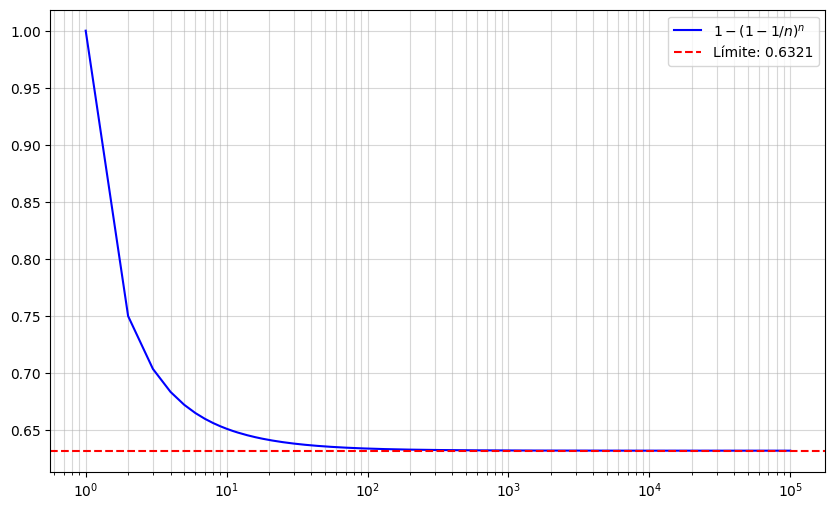

In [166]:
#(G) Create a plot that displays, for each integer value of n from 1 to 100, 000, the probability that the jth observation is in the bootstrap sample. Comment on what you observe.
n = np.arange(1, 100001)

# Calcular la probabilidad: 1 - (1 - 1/n)^n
probabilidad = 1 - (1 - 1/n)**n

# Crear la gráfica
plt.figure(figsize=(10, 6))
plt.plot(n, probabilidad,label=r'$1 - (1 - 1/n)^n$', color='blue')

# Añadir la línea del límite asintótico (1 - 1/e)
limite = 1 - 1/np.exp(1)
plt.axhline(y=limite, color='red', linestyle='--', label=f'Límite: {limite:.4f}')

# Configuración de etiquetas y escalas
plt.xscale('log')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.show()



Observaciones: Conforme el valor aumenta la línea va tendiendo al límite

## Aplicados



In [167]:
#from google.colab import files
#ಥ_ಥ = files.upload()

### A) 
Fit a logistic regression model that uses income and balance to predict default.

In [168]:
df= pd.read_csv('Default.csv')
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  object 
 1   student  10000 non-null  object 
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB


In [170]:
X_num= df[["balance", "income"]]
df["student"]= df['student']
X_cat= df[["student"]]
y= df["default"]
y= np.where(y=="Yes", 1, 0)


In [171]:
model = LogisticRegression()

In [172]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), X_num.columns),
        ("cat", OneHotEncoder(drop="first"), X_cat.columns)
    ]
)
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor), 
    ("model", model)
])
X= X_num.join(X_cat)
pipeline.fit(X, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [173]:
y_pred = pipeline.predict(X)
print("Predicciones:", y_pred)
#sacarle dummies a la y_pred: No 0, yes 1



Predicciones: [0 0 0 ... 0 0 0]


### B)
Using the validation set approach, estimate the test error of this model. In order to do this, you must perform the following steps:

i. Split the sample set into a training set and a validation set.

ii. Fit a multiple logistic regression model using only the training observations.

iii. Obtain a prediction of default status for each individual in the validation set by computing the posterior probability of default for that individual, and classifying the individual to the default category if the posterior probability is greater than 0.5.

iv. Compute the validation set error, which is the fraction of the observations in the validation set that are misclassified.

In [174]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.6, random_state=42)
pipeline.fit(X_train, y_train)
y_val_pred = pipeline.predict(X_val)
y_val_pred_proba = pipeline.predict_proba(X_val)[:, 1]
predictions_val = (y_val_pred_proba > 0.5).astype(int)



In [175]:
validation_error = np.mean(predictions_val != y_val)
print("Error de validación:", validation_error)

Error de validación: 0.03


### C) 
Repeat the process in (b) three times, using three different splits of the observations into a training set and a validation set. Comment on the results obtained.

In [176]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.8, random_state=42)
pipeline.fit(X_train, y_train)
y_val_pred = pipeline.predict(X_val)
y_val_pred_proba = pipeline.predict_proba(X_val)[:, 1]
predictions_val = (y_val_pred_proba > 0.5).astype(int)

In [177]:
validation_error = np.mean(predictions_val != y_val)
print("Error de validación:", validation_error)

Error de validación: 0.04


In [178]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.8, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)
y_val_pred = pipeline.predict(X_val)
y_val_pred_proba = pipeline.predict_proba(X_val)[:, 1]
predictions_val = (y_val_pred_proba > 0.5).astype(int)

In [179]:
validation_error = np.mean(predictions_val != y_val)
print("Error de validación:", validation_error)

Error de validación: 0.0271875


In [180]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.5, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
pipeline.fit(X_train, y_train)
y_val_pred = pipeline.predict(X_val)
y_val_pred_proba = pipeline.predict_proba(X_val)[:, 1]
predictions_val = (y_val_pred_proba > 0.5).astype(int)

In [181]:
validation_error = np.mean(predictions_val != y_val)
print("Error de validación:", validation_error)

Error de validación: 0.0264


Los resultados obtenidos fueron más o menos lo mismo a pesar de haber movido los tamaños cada vez.

### D)
 Now consider a logistic regression model that predicts the probability of default using income, balance, and a dummy variable
for student. Estimate the test error for this model using the validation set approach. Comment on whether or not including a
dummy variable for student leads to a reduction in the test error
rate.


In [182]:
df["student"]= np.where(df['student']=="Yes", 1, 0)
df["student"]

0       0
1       1
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    1
Name: student, Length: 10000, dtype: int64

In [183]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), X_num.columns),
    ]
)
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor), 
    ("model", model)
])
X= X_num.join(X_cat)
pipeline.fit(X, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [184]:
y_pred = pipeline.predict(X)
print("Predicciones:", y_pred)

Predicciones: [0 0 0 ... 0 0 0]


In [185]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.8, random_state=42)
pipeline.fit(X_train, y_train)
y_val_pred = pipeline.predict(X_val)
y_val_pred_proba = pipeline.predict_proba(X_val)[:, 1]
predictions_val = (y_val_pred_proba > 0.5).astype(int)

In [186]:
validation_error = np.mean(predictions_val != y_val)
print("Error de validación:", validation_error)

Error de validación: 0.0375


En este caso el error me aumentó un poco porque en el ejercicio anterior lo hice con one hot encoder, así que probablemente lo sesgué un poco más ahora con los dummies porque yo elegí cual era uno y cual era 0

We continue to consider the use of a logistic regression model to predict the probability of default using income and balance on the Default data set. In particular, we will now compute estimates for the standard errors of the income and balance logistic regression coefficients in two different ways: (1) using the bootstrap, and (2) using the standard formula for computing the standard errors in the sm.GLM() function. Do not forget to set a random seed before beginning your analysis.
(a) Using the summarize() and sm.GLM() functions, determine the estimated standard errors for the coefficients associated with income and balance in a multiple logistic regression model that uses both predictors. (b) Write a function, boot_fn(), that takes as input the Default data set as well as an index of the observations, and that outputs the coefficient estimates for income and balance in the multiple logistic regression model. (c) Following the bootstrap example in the lab, use your boot_fn() function to estimate the standard errors of the logistic regression coefficients for income and balance. (d) Comment on the estimated standard errors obtained using the sm.GLM() function and using the bootstrap.

In [187]:
np.random.seed(42)

In [188]:
X_num= sm.add_constant(X_num)

In [189]:
model_glm = sm.GLM(y, X_num ).fit()
print(model_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9997
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                        0.028217
Method:                          IRLS   Log-Likelihood:                 3651.3
Date:                Sat, 16 May 2026   Deviance:                       282.08
Time:                        18:33:12   Pearson chi2:                     282.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.1316
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0922      0.006    -15.936      0.0

In [190]:
se_glm = model_glm.bse
print(se_glm[['income', 'balance']])

income     1.274443e-07
balance    3.513801e-06
dtype: float64


In [191]:
df['default']= np.where(df['default']==1, 1, 0)

In [201]:
y = df["default"]
y = np.where(y == "Yes", 1, 0)
df['default'] = np.where(df['default'] == 1, 1, 0)

In [205]:
def boot_fn(data, index):
    """
    Calcula los coeficientes manteniendo la estructura de Pandas para conservar las etiquetas.
    """
    clean_index = np.asarray(index).astype(int).flatten()
    sub_sample = data.iloc[clean_index]
    
    # Conservamos Pandas para que las columnas mantengan sus nombres ('income', 'balance')
    X_boot = sub_sample[['income', 'balance']]
    X_boot = sm.add_constant(X_boot) 
    
    # Llamamos a tu columna dummie (cámbialo por 'default_num' si así la nombraste)
    y_boot = sub_sample['default'].astype(int)
    
    # Ajustamos con Logit para garantizar estabilidad numérica en el remuestreo
    fit_boot = sm.Logit(y_boot, X_boot).fit(disp=0)
    
    # Retorna los coeficientes buscándolos directamente por su nombre
    return fit_boot.params[['income', 'balance']]

In [206]:
# Inicializar parámetros
n_observations = len(df)
B = 1000
boot_coefs = []

# Configurar la semilla aleatoria requerida por el ejercicio
np.random.seed(42)

print("Corriendo Bootstrap...")

for i in range(B):
    # Generar un arreglo plano de enteros para las posiciones del remuestreo
    boot_indices = np.random.randint(0, n_observations, size=n_observations)
    
    # Guardar los coeficientes de esta iteración
    coefs = boot_fn(df, boot_indices)
    boot_coefs.append(coefs)

# Convertir la lista a DataFrame asignando sus columnas correspondientes
df_boot_coefs = pd.DataFrame(boot_coefs, columns=['income', 'balance'])

# Calcular la desviación estándar (Error Estándar del Bootstrap)
se_bootstrap = df_boot_coefs.std(axis=0)

print("\n--- Errores Estándar Estimados por Bootstrap ---")
print(se_bootstrap)

Corriendo Bootstrap...


C:\Users\eugen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
C:\Users\eugen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
C:\Users\eugen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=Perfec


--- Errores Estándar Estimados por Bootstrap ---
income     0.000021
balance    0.000457
dtype: float64


C:\Users\eugen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
C:\Users\eugen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
C:\Users\eugen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=Perfec

Los errores estándar de ambos métodos son casi idénticos, variando apenas por unos decimales.

El modelo es confiable porque:

Los supuestos teóricos se cumplen: El método tradicional de sm.GLM asume que los datos siguen una distribución específica. Al dar el mismo resultado que el Bootstrap (que es un método empírico que no asume nada y trabaja directo con los datos reales), se confirma que el modelo teórico se ajusta perfectamente a la estructura de los datos.

Las estimaciones son estables: La coincidencia tan exacta entre ambos enfoques demuestra que la variabilidad calculada para los efectos de income y balance es real, robusta y libre de sesgos provocados por anomalías o el desbalance de clases en el dataset.